# Fitting more complex models to photometry with Bagpipes

In the previos example we covered some of the basics, now let's look at fitting a more complex model.

## Setting up

Once again we'll need to load up the observational data, we'll use the same object as last time.

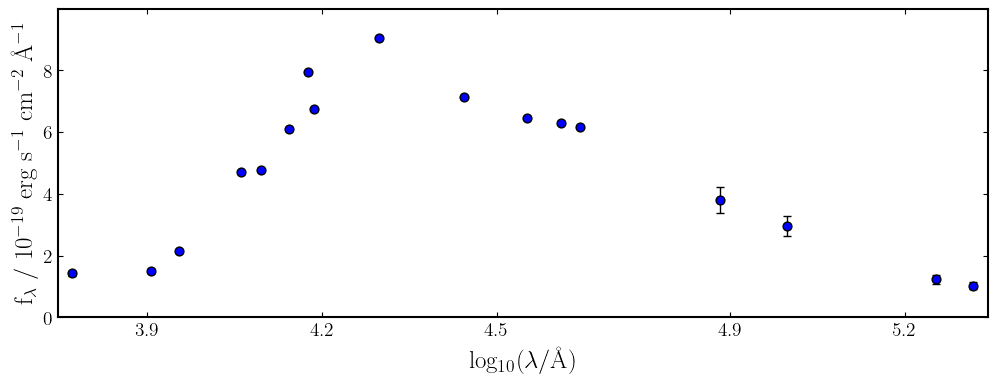

In [ ]:
import numpy as np 
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

import bagpipes as pipes
import matplotlib.pyplot as plt
#%matplotlib inline

from astropy.io import fits
from astropy.table import Table

def load_bluejay(ID):
    """ Load BlueJay photometry from the BlueJay catalogue(s)"""

    # Blue Jay catalogue
    bluejay_cat = Table.read("bluejay_phot_cat_v1.4.fits")
    
    # 1. List all available HST/NIRCam bands:
    filters = ['F090W', 'F115W', 'F125W', 'F140W', 'F150W', 'F160W', 
               'F200W', 'F277W', 'F356W', 'F410M', 'F444W', 'F606W', 'F814W']
    
    # 2. Find the correct row using the ID column
    # Use a mask rather than (int(ID) - 1) to be safe against non-sequential IDs
    row = bluejay_cat[bluejay_cat['ID'] == int(ID)]

    if len(row) == 0:
        raise ValueError(f"ID {ID} not found in catalogue.")
    
    # 3. Extract fluxes and errors into lists
    fluxes = []
    flux_errs = []

    for f in filters:
        fluxes.append(row[f + "_flux"][0] * 1e6)
        flux_errs.append(row[f + "_flux_err"][0] * 1e6)


    # MIRI catalogue
    miri_cat = Table.read("Phot_Table_MIRI.fits")
    
    # 1. List all available MIRI bands:
    miri_filters = ['F770W', 'F1000W', 'F1800W', 'F2100W']
    
    # 2. Find the correct row using the ID column
    # Use a mask rather than (int(ID) - 1) to be safe against non-sequential IDs
    row = miri_cat[miri_cat['ID'] == int(ID)]

    if len(row) == 0:
        raise ValueError(f"ID {ID} not found in catalogue.")
    
    # 3. Extract fluxes and errors into lists
    for f in miri_filters:
        fluxes.append(row[f + "_flux"][0] * 1e6)
        flux_errs.append(row[f + "_flux_err"][0] * 1e6)
    
    # Now turn these into a 2D array [N_filters, 2]
    # Bagpipes expects photometry[i, 0] = flux, photometry[i, 1] = error
    photometry = np.c_[fluxes, flux_errs]
    
    # 5. Clean up missing data and enforce SNR limits
    for i in range(len(photometry)):
        # Blow up errors for missing data (NaN or 0 flux)
        if (photometry[i, 0] <= 0.) or (np.isnan(photometry[i, 0])):
            photometry[i, :] = [0., 9.9e99]
            continue # Skip SNR check for bad data
    
    return photometry

bluejay_filt_list = np.loadtxt("filters/bluejay_filt_list.txt", dtype="str")

galaxy = pipes.galaxy("12020", load_bluejay, spectrum_exists=False, filt_list=bluejay_filt_list)

fig = galaxy.plot()

# Replicating the Prospector Model

Specify all parameters such that they match the Prospector model that Letizia used for my galaxies.

Prospector Parameter    Bagpipes Equivalent     Translation Notes
zred                    redshift                "Use (1.764, 0.5) for a Gaussian."
logzsol                 metallicity             Convert log to linear (10−2 to 100.5).
logmass                 massformed              "Bagpipes uses total formed mass, not current stellar mass."
dust2                   Av                      AV​=1.086×optical depth.
dust_index              eta                     Bagpipes' cf00 model uses eta for the slope.

## Making a more interesting model

Instead of an ordinary tau model let's try fitting a double-power-law star-formation history, we'll also include nebular emission this time. This is also a good time to think about the priors we're imposing on our fitting parameters. By default Bagpipes will fit a uniform prior between the limits you set, but you can change that as follows:

In [135]:
dblplaw = {}                        
dblplaw["tau"] = (0., 15.)                # Vary the time of peak star-formation between
                                          # the Big Bang at 0 Gyr and 15 Gyr later. In 
                                          # practice the code automatically stops this
                                          # exceeding the age of the universe at the 
                                          # observed redshift.
            
dblplaw["alpha"] = (0.01, 1000.)          # Vary the falling power law slope from 0.01 to 1000.
dblplaw["beta"] = (0.01, 1000.)           # Vary the rising power law slope from 0.01 to 1000.
dblplaw["alpha_prior"] = "log_10"         # Impose a prior which is uniform in log_10 of the 
dblplaw["beta_prior"] = "log_10"          # parameter between the limits which have been set 
                                          # above as in Carnall et al. (2017).
dblplaw["massformed"] = (1., 15.)
dblplaw["metallicity"] = (0., 2.5)

dust = {}                           
dust["type"] = "Calzetti"
dust["Av"] = (0., 2.)

nebular = {}
nebular["logU"] = -3.

fit_info = {}                            # The fit instructions dictionary
fit_info["redshift"] = (0., 10.)         # Vary observed redshift from 0 to 10

fit_info["redshift_prior"] = "Gaussian"  # From looking at the spectrum in Example 2 it's
fit_info["redshift_prior_mu"] = 1.0      # clear that this  object is at around z = 1. We'll 
fit_info["redshift_prior_sigma"] = 0.25  # include that information with a broad Gaussian
                                         # prior centred on redshift 1. Parameters of priors
                                         # are passed starting with "parameter_prior_".
fit_info["dblplaw"] = dblplaw 
fit_info["dust"] = dust
fit_info["nebular"] = nebular

# Fitting the same object multiple times with different runs

Now we're ready to fit the object, but there's a problem, the posterior distribution for the previous example is still there. We can fit a fresh model without deleting our previous outputs by setting the run keyword argument of the fit object, which causes the output posterior to be saved under "pipes/posterior/run" instead "pipes/posterior" and the same for output plots.

In [170]:
# Redshift
def get_zred(galaxy_id):    
    # --- Read Blue Jay catalogue ---
    blue = "/Users/benjamincollins/University/Master/BlueJay/BlueJay_sample.txt"
    tbl = Table.read(blue, format="ascii.basic")
    
    row = tbl[tbl['id'] == int(galaxy_id)]
    z_spec = row['z_spec'][0]
    
    if z_spec is not None and not np.isnan(z_spec):
        return z_spec, True
    else:
        z_phot = row['z_phot'][0]
        return z_phot, False

# Star formation histories
def zred_to_agebins(zred, z_limit_sfh=20.0, nbins_sfh=8):
    tuniv = cosmo.age(zred).value*1e9   # Age of the universe at the observed redshift in years
    #tbinmax = tuniv-cosmo.age(z_limit_sfh).value*1e9 # Maximum age bin edge corresponding to z_limit_sfh
    tbinmax = tuniv*0.95
    # Compute edges in logarithmic space
    log_edges = np.append(np.array([0.0, 6.7, 7.0]), np.linspace(7.0, np.log10(tbinmax), int(nbins_sfh-1))[1:])
    bin_edges = 10**log_edges   # Convert back to linear space
    bin_edges /= 1e6 # ensure that edges are in Myr for Bagpipes
    return bin_edges.tolist()   # return list of age bin edges

fit_instructions = {}                       # The fit instructions dictionary

# Nebular component
nebular = {}
nebular["logU"] = (-4., -1.)                # Log_10 of the ionisation parameter.
nebular["fesc"] = (0., 1.)                  # IMPORTANT: Escape fraction of ionising photons. Standard value is 0.1

# Dust absorption parameters
dust = {}                               # Dust component
dust["type"] = "CF00"                   # Define the shape of the attenuation curve
dust["Av"] = (0., 4.0)                  # Vary Av between 0 and 3.2 magnitudes
dust["n"] = (-1.0, 1.5)                 # Vary the slope of the attenuation curve from -1.0 to 1.5
dust["n_prior"] = "Gaussian"            # Set a Gaussian prior
dust["n_prior_mu"] = 0.7                # Centred on the standard CF00 slope of 0.7
dust["n_prior_sigma"] = 0.3             # With a width of 0.3

# Dust emission parameters (now free parameters)
dust["qpah"] = (0.1, 4.58)                  # PAH mass fraction (spanning the entire grid)
dust["umin"] = (0.1, 25.)                   # Lower limit of starlight intensity distribution (spanning the entire grid)
dust["gamma"] = (0., 1.0)                   # Fraction of stars at Umin

# Alternatively use a very narrow Gaussian prior centred on the spectroscopic redshift:
#fit_instructions["redshift"] = (zred-1, zred+1)     # Set the redshift prior to vary within +/1 of the spectroscopic redshift
#fit_instructions["redshift_prior"] = "Gaussian"     # Use a Gaussian prior
#fit_instructions["redshift_prior_mu"] = zred        # Centred on the spectroscopic redshift
#fit_instructions["redshift_prior_sigma"] = 0.005    # With a very narrow width

# Setting the SFH priors
continuity = {}
continuity["massformed"] = (8.5, 12.5)        # Log10 of solar mass formed
continuity["metallicity"] = (0.01, 2.5)       # Linear Z/Z_solar: 0.01 to 3.16

# Define the dsfr ratios
for i in range(1, 7):   # for 7 bins
    continuity[f"dsfr{i}"] = (-10., 10.) 
    continuity[f"dsfr{i}_prior"] = "student_t"
    #continuity["dsfr" + str(i) + "_prior_df"] = 2       # Default nu value of 2 in the student_t distribution
    #continuity["dsfr" + str(i) + "_prior_scale"] = 0.3  # Default sigma value of 0.3 in the student_t distribution

fit_instructions["dust"] = dust
fit_instructions["nebular"] = nebular
fit_instructions["continuity"] = continuity

print(fit_instructions)

{'dust': {'type': 'CF00', 'Av': (0.0, 4.0), 'n': (-1.0, 1.5), 'n_prior': 'Gaussian', 'n_prior_mu': 0.7, 'n_prior_sigma': 0.3, 'qpah': (0.1, 4.58), 'umin': (0.1, 25.0), 'gamma': (0.0, 1.0)}, 'nebular': {'logU': (-4.0, -1.0), 'fesc': (0.0, 1.0)}, 'continuity': {'massformed': (8.5, 12.5), 'metallicity': (0.01, 2.5), 'dsfr1': (-10.0, 10.0), 'dsfr1_prior': 'student_t', 'dsfr2': (-10.0, 10.0), 'dsfr2_prior': 'student_t', 'dsfr3': (-10.0, 10.0), 'dsfr3_prior': 'student_t', 'dsfr4': (-10.0, 10.0), 'dsfr4_prior': 'student_t', 'dsfr5': (-10.0, 10.0), 'dsfr5_prior': 'student_t', 'dsfr6': (-10.0, 10.0), 'dsfr6_prior': 'student_t'}}


Now run the galaxy with minimal parameters

In [ ]:
# Step 1: Get all IDs from the MIRI catalogue
miri_table = "./Phot_Table_MIRI.fits"
id_table = Table.read(miri_table)
all_ids = [int(val.decode('utf-8') if isinstance(val, bytes) else val) 
                        for val in id_table['ID']]

# Step 2: Loop over all IDs, load the galaxy, set the redshift and SFH priors, and fit each one!
for objid in all_ids:
    # Create galaxy object for the current ID
    galaxy = pipes.galaxy(f"{objid}", load_bluejay, spectrum_exists=False, filt_list=bluejay_filt_list)

    # Load the redshift
    zred, is_spectroscopic = get_zred(objid)
    if is_spectroscopic:
        print(f"Fixing redshift to the spectroscopic value of the source: {zred}")
        fit_instructions["redshift"] = zred                       # Fix the redshift to the spectroscopic value to reduce runtime
    else:
        print(f"Using photometric redshift of {zred} with a Gaussian prior for the source.")
        fit_instructions["redshift"] = (zred-0.25, zred+0.25)     # Set the redshift prior to vary within +/1 of the photometric redshift
        fit_instructions["redshift_prior"] = "Gaussian"           # Use a Gaussian prior
        fit_instructions["redshift_prior_mu"] = zred              # Centred on the photometric redshift
        fit_instructions["redshift_prior_sigma"] = 0.05           # With a width of 0.05

    # Calculate the agebins for the star formation history of the galaxy based on its redshift and update the fit instructions
    age_bins = zred_to_agebins(zred, nbins_sfh=7)
    print("Age bins:", age_bins)
    fit_instructions["continuity"]["bin_edges"] = age_bins   
    
    fit = pipes.fit(galaxy, fit_instructions, run="fesc_free")

    fit.fit(verbose=True, sampler='nautilus', pool=4, discard_exploration=True)

    fig = fit.plot_spectrum_posterior(save=True, show=False)
    fig = fit.plot_sfh_posterior(save=True, show=False)
    fig = fit.plot_corner(save=True, show=False) 

Fixing redshift to the spectroscopic value of the source: 2.654
Age bins: [1e-06, 5.011872336272725, 10.0, 29.839925206018638, 89.04211363007866, 265.701001090736, 792.8497999711839, 2365.8578730746967]

Results loaded from pipes/posterior/fesc_free/12213.h5

Fitting not performed as results have already been loaded from pipes/posterior/fesc_free/12213.h5. To start over delete this file or change run.



/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3559: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/lib/_index_tricks_impl.py:414: UserWarning: Warning: converting a masked element to nan.
  newobj = array(item, copy=None, subok=True, ndmin=ndmin)


Fixing redshift to the spectroscopic value of the source: 3.001881
Age bins: [1e-06, 5.011872336272725, 10.0, 29.047378541092392, 84.37502001095147, 245.0873145670358, 711.9144001848462, 2067.9247071024]

Results loaded from pipes/posterior/fesc_free/16615.h5

Fitting not performed as results have already been loaded from pipes/posterior/fesc_free/16615.h5. To start over delete this file or change run.



/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3559: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/lib/_index_tricks_impl.py:414: UserWarning: Warning: converting a masked element to nan.
  newobj = array(item, copy=None, subok=True, ndmin=ndmin)


Fixing redshift to the spectroscopic value of the source: 2.098
Age bins: [1e-06, 5.011872336272725, 10.0, 31.323716779366165, 98.11752328739453, 307.34055105472044, 962.704837605241, 3015.54936752722]

Results loaded from pipes/posterior/fesc_free/11137.h5

Fitting not performed as results have already been loaded from pipes/posterior/fesc_free/11137.h5. To start over delete this file or change run.



...

Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 50     | 1        | 4        | 95700    | N/A    | 195   | +49.55   

Completed in 975.3 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
continuity:dsfr1               0.231      0.432      0.836
continuity:dsfr2               0.420      0.694      1.238
continuity:dsfr3               0.748      1.214      2.119
continuity:dsfr4               0.392      0.670      1.139
continuity:dsfr5              -0.519     -0.373    

/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3559: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/lib/_index_tricks_impl.py:414: UserWarning: Warning: converting a masked element to nan.
  newobj = array(item, copy=None, subok=True, ndmin=ndmin)


Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 40     | 2        | 4        | 95800    | N/A    | 63    | +59.29   

Completed in 828.0 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
continuity:dsfr1               0.255      0.480      1.079
continuity:dsfr2               0.594      0.873      1.410
continuity:dsfr3               0.641      1.013      1.325
continuity:dsfr4              -0.185      0.028      0.187
continuity:dsfr5              -0.363     -0.237    

/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3559: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/lib/_index_tricks_impl.py:414: UserWarning: Warning: converting a masked element to nan.
  newobj = array(item, copy=None, subok=True, ndmin=ndmin)


Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
